# Problem Statement : Life Expectancy Prediction

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

## Load data

In [5]:
df = pd.read_csv('data/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Data Overview

In [7]:
df.shape

(2938, 22)

In [8]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [10]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Observations :
- The minimum value of 1 seems implausibly low for adult mortality.
- The maximum value of 1,800 is extremely high, possibly indicating data errors or outliers for infant deaths.
-  The maximum value seems unusually high and may indicate incorrect data scaling for persentage expenditure.
- Extremely high maximum value suggests potential outliers for Measles.
- The minimum value of 1 seems unrealistic for BMI.
- Maximum value is extremely high and may need verification for under-five deaths.
- The maximum value of 50.6% reflects regions with severe epidemics (HIV/AIDS).
- Extreme disparities in GDP indicate global economic inequality.
- Wide range is expected but may include countries with very low populations.


## Fix Data Types, Check Duplicate and Missing values

In [13]:
# fixing feature names
df.rename(columns=lambda x: x.replace(' ', ''), inplace=True)

In [14]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

In [15]:
df.rename(columns={'thinness1-19years': 'thinness10-19years'}, inplace=True)

In [16]:
# check for duplicates
df.duplicated().sum()

0

In [17]:
# missing values
df.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                   10
AdultMortality                   10
infantdeaths                      0
Alcohol                         194
percentageexpenditure             0
HepatitisB                      553
Measles                           0
BMI                              34
under-fivedeaths                  0
Polio                            19
Totalexpenditure                226
Diphtheria                       19
HIV/AIDS                          0
GDP                             448
Population                      652
thinness10-19years               34
thinness5-9years                 34
Incomecompositionofresources    167
Schooling                       163
dtype: int64

In [18]:
missing_values_percentage = df.isnull().sum() / len(df) * 100
missing_values_percentage

Country                          0.000000
Year                             0.000000
Status                           0.000000
Lifeexpectancy                   0.340368
AdultMortality                   0.340368
infantdeaths                     0.000000
Alcohol                          6.603131
percentageexpenditure            0.000000
HepatitisB                      18.822328
Measles                          0.000000
BMI                              1.157250
under-fivedeaths                 0.000000
Polio                            0.646698
Totalexpenditure                 7.692308
Diphtheria                       0.646698
HIV/AIDS                         0.000000
GDP                             15.248468
Population                      22.191967
thinness10-19years               1.157250
thinness5-9years                 1.157250
Incomecompositionofresources     5.684139
Schooling                        5.547992
dtype: float64

In [19]:
df.nunique()

Country                          193
Year                              16
Status                             2
Lifeexpectancy                   362
AdultMortality                   425
infantdeaths                     209
Alcohol                         1076
percentageexpenditure           2328
HepatitisB                        87
Measles                          958
BMI                              608
under-fivedeaths                 252
Polio                             73
Totalexpenditure                 818
Diphtheria                        81
HIV/AIDS                         200
GDP                             2490
Population                      2278
thinness10-19years               200
thinness5-9years                 207
Incomecompositionofresources     625
Schooling                        173
dtype: int64

## Univariate Analysis

<Axes: xlabel='Lifeexpectancy'>

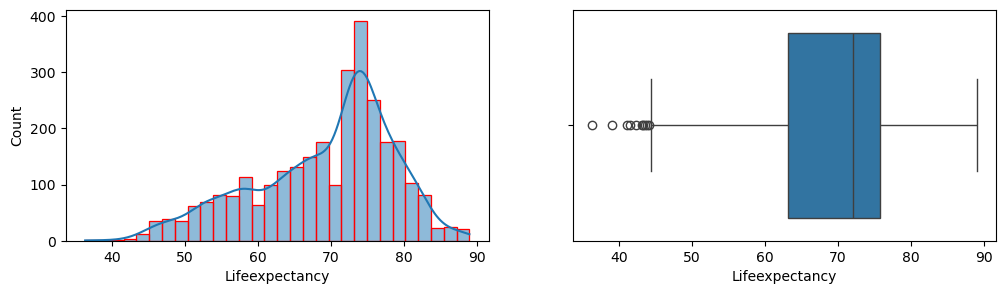

In [21]:
# histogram for the Lifeexpectancy
plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=df,
             x='Lifeexpectancy',
             kde=True,
             edgecolor='red')
plt.subplot(1, 2, 2)
sns.boxplot(data=df,x='Lifeexpectancy')

In [22]:
df['Country'].value_counts()

Country
Afghanistan              16
Peru                     16
Nicaragua                16
Niger                    16
Nigeria                  16
                         ..
Niue                      1
San Marino                1
Nauru                     1
Saint Kitts and Nevis     1
Dominica                  1
Name: count, Length: 193, dtype: int64

In [23]:
df['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

In [24]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

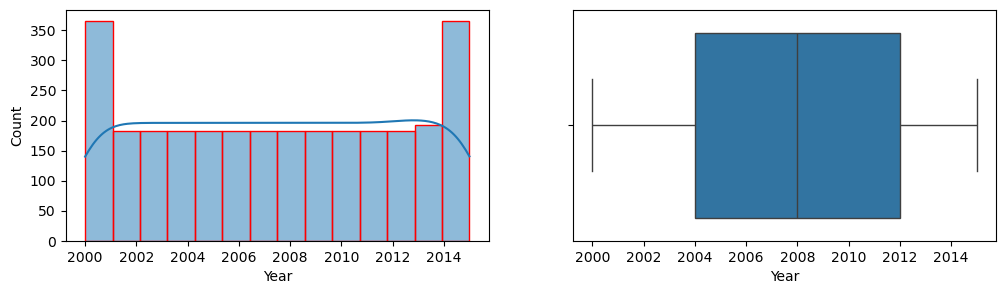

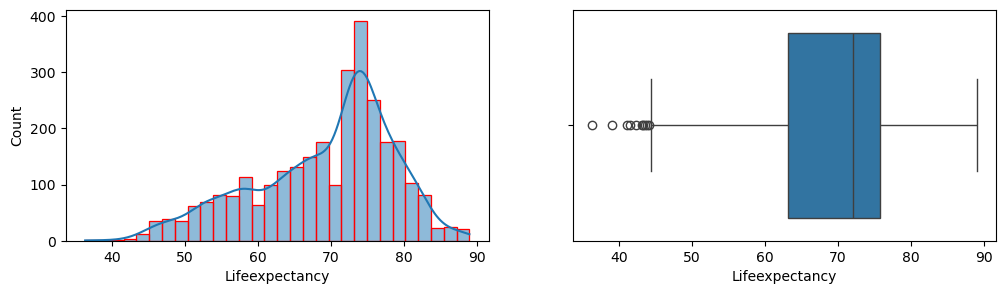

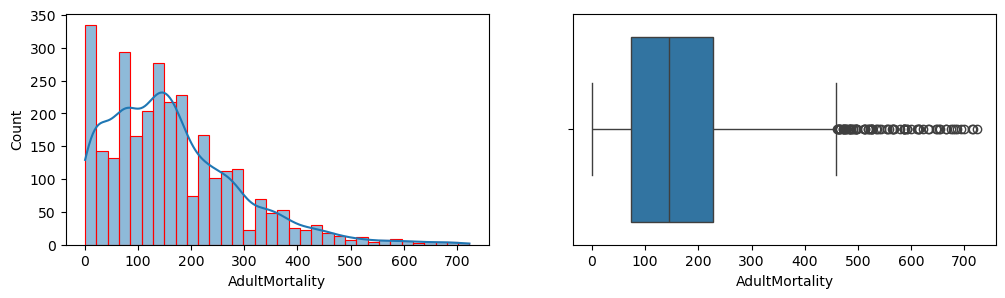

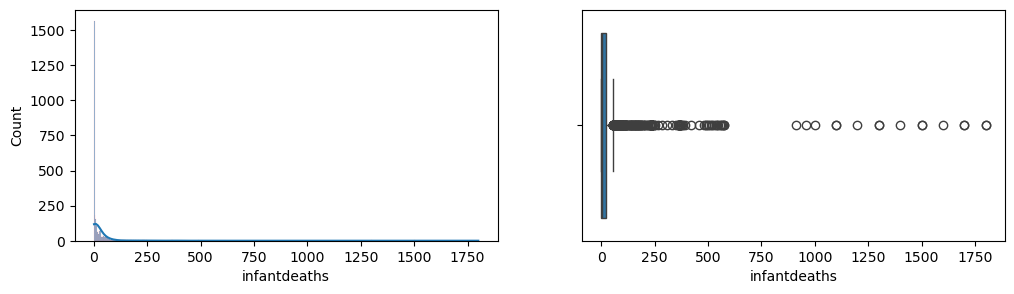

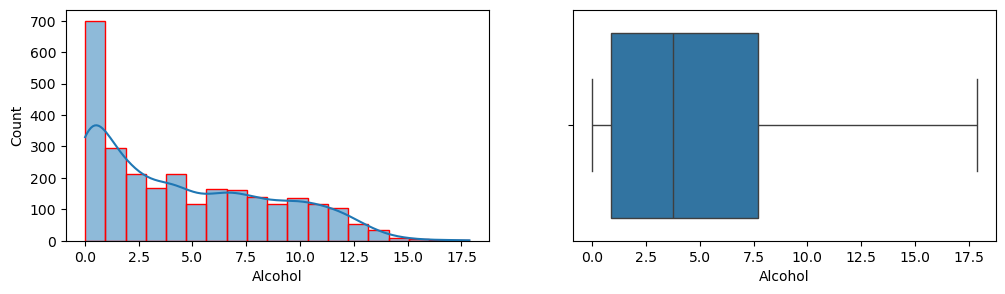

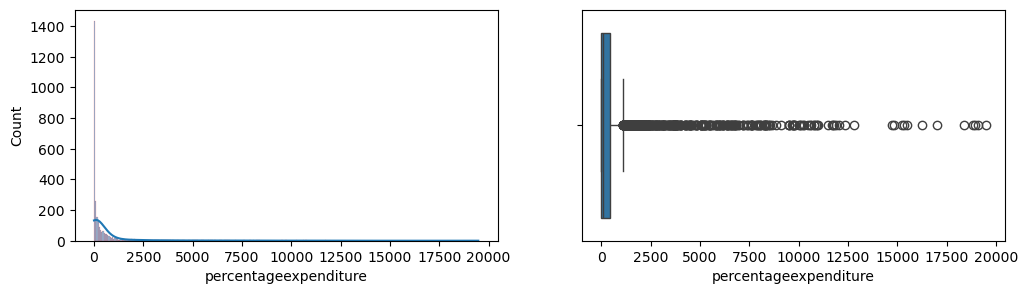

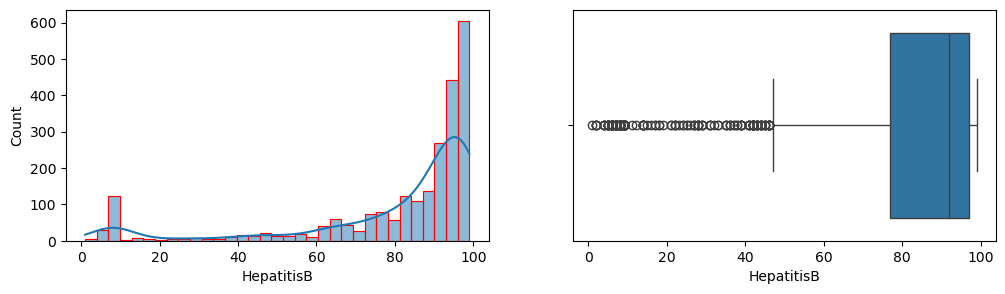

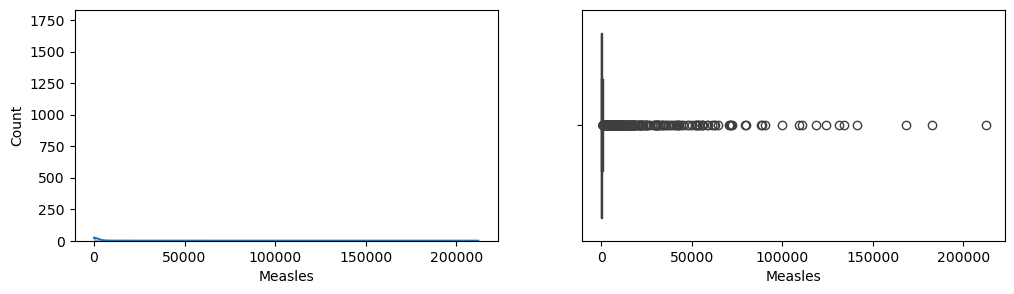

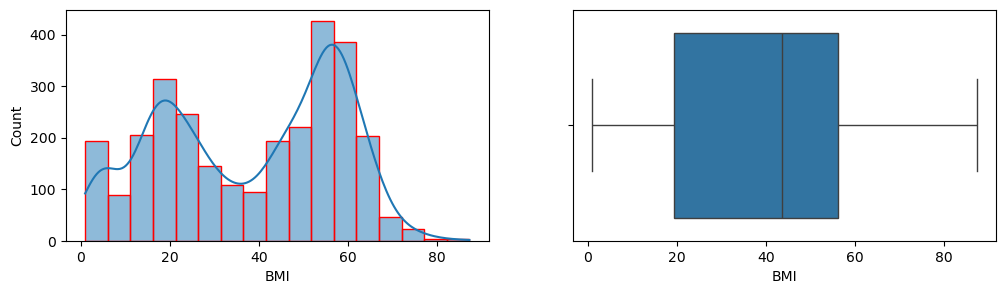

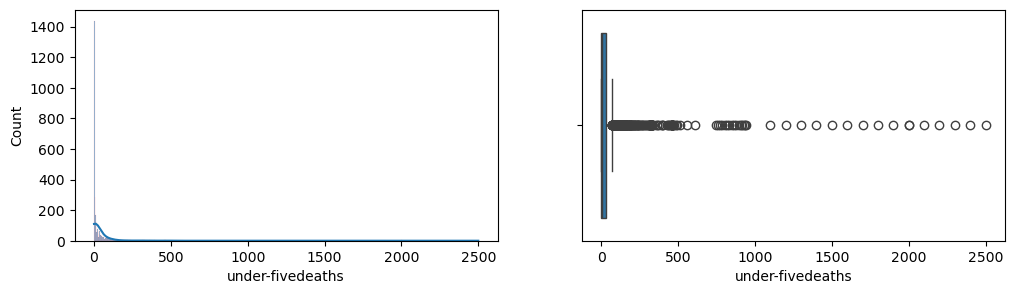

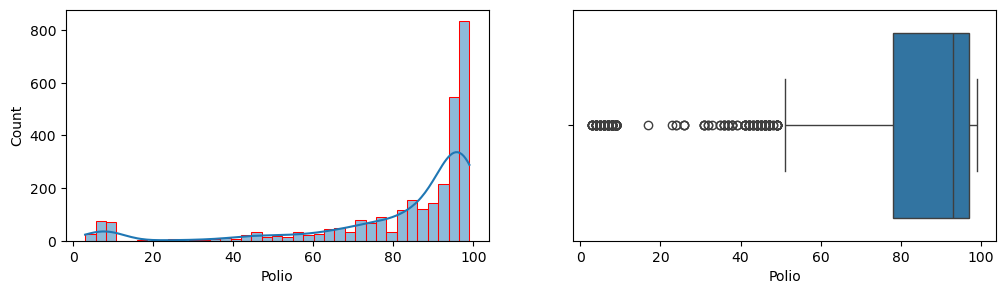

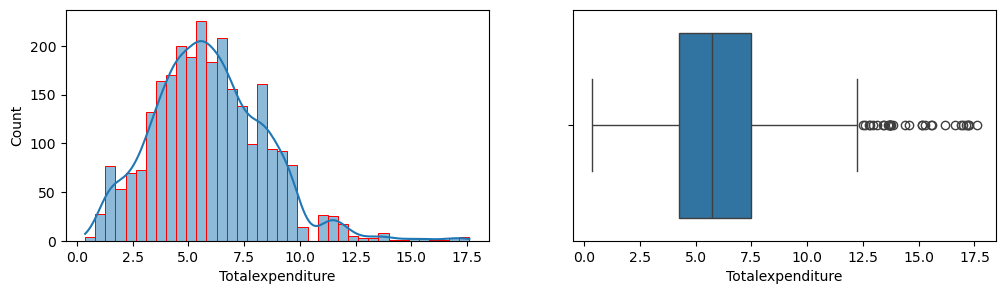

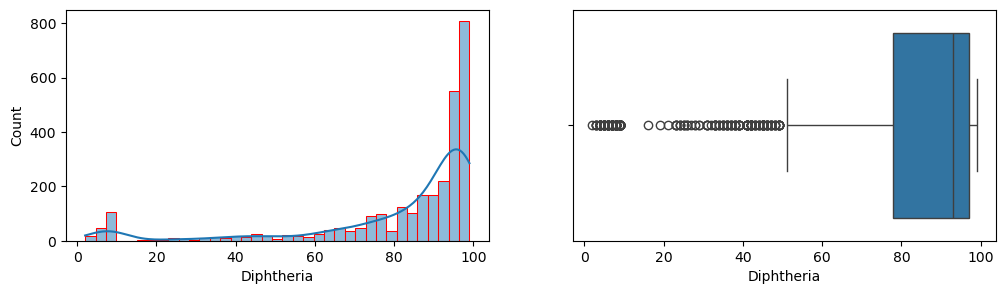

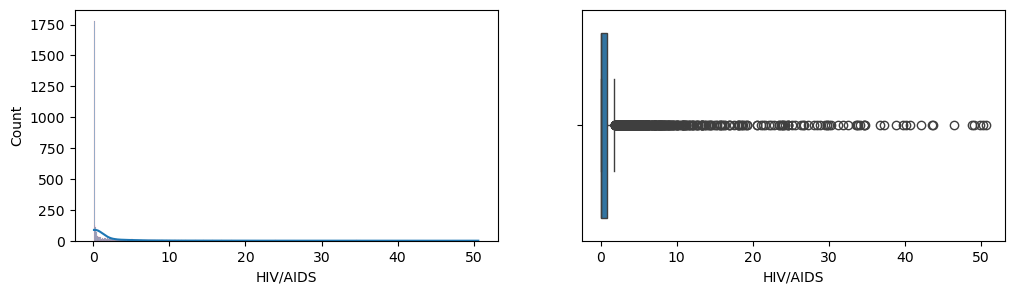

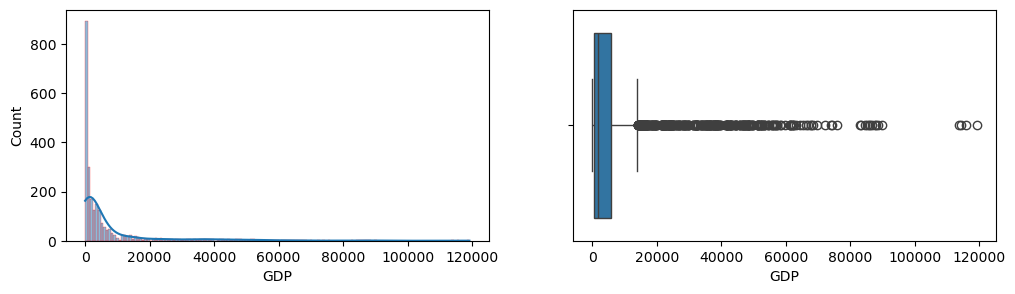

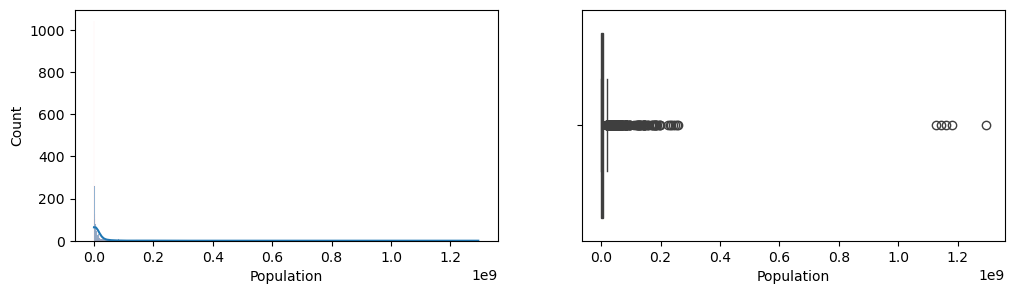

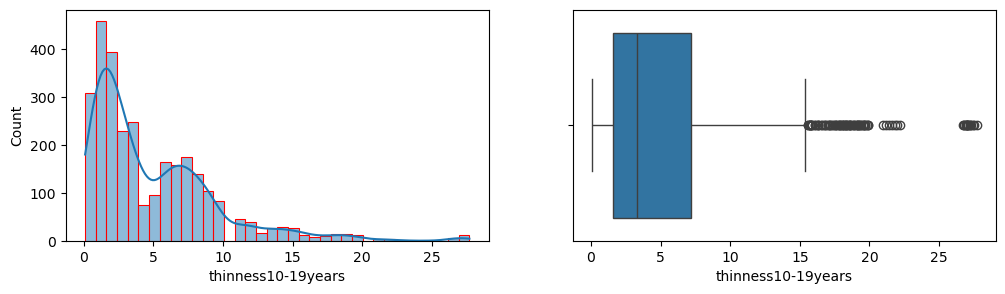

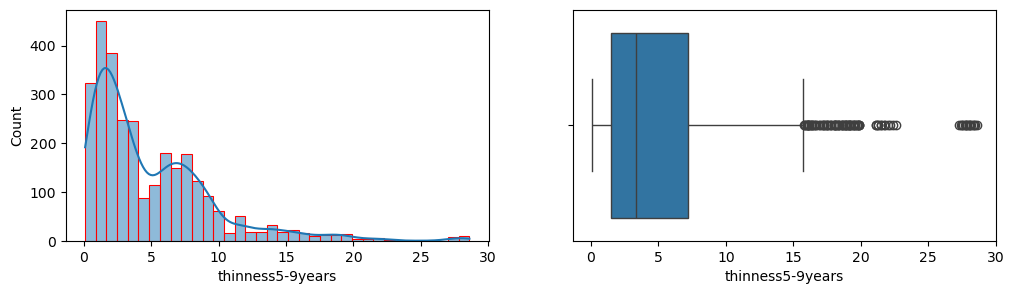

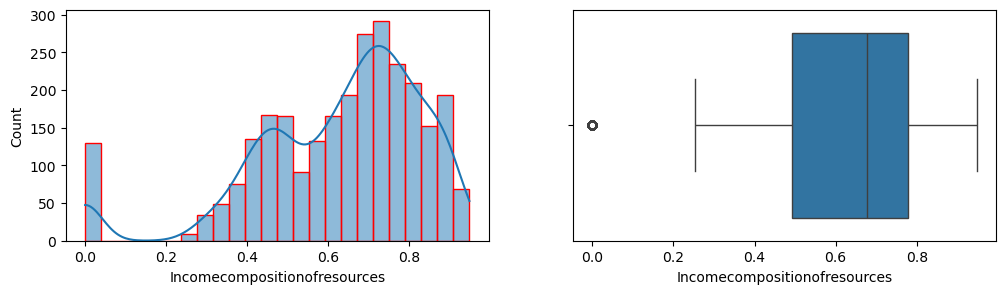

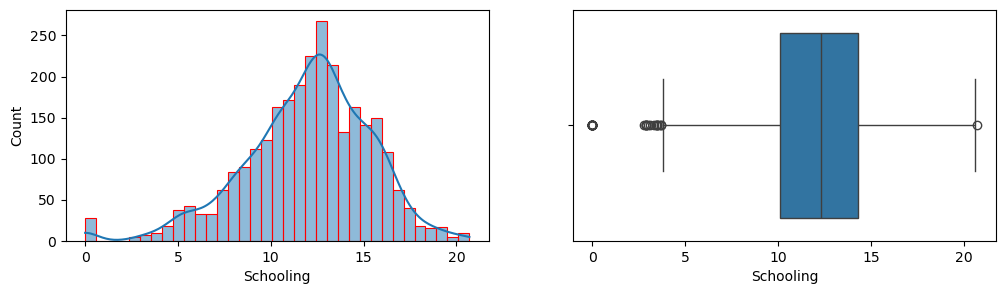

In [25]:
# histogram and boxplot for all numerical columns

for i in df.columns:
  if df[i].dtype == 'float64' or df[i].dtype == 'int64':

    plt.figure(figsize=(12, 3))

    # histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data=df,
                x=i,
                kde=True,
                edgecolor='red')

    # boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df,x=i)

## Bivariate Analysis

In [27]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

<Axes: xlabel='Status', ylabel='Lifeexpectancy'>

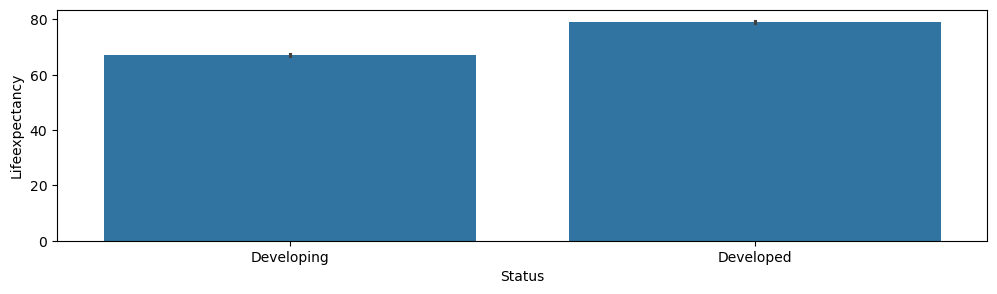

In [28]:
# Life expectancy vs country
plt.figure(figsize=(12, 3))
sns.barplot(data=df,x='Status',y='Lifeexpectancy')

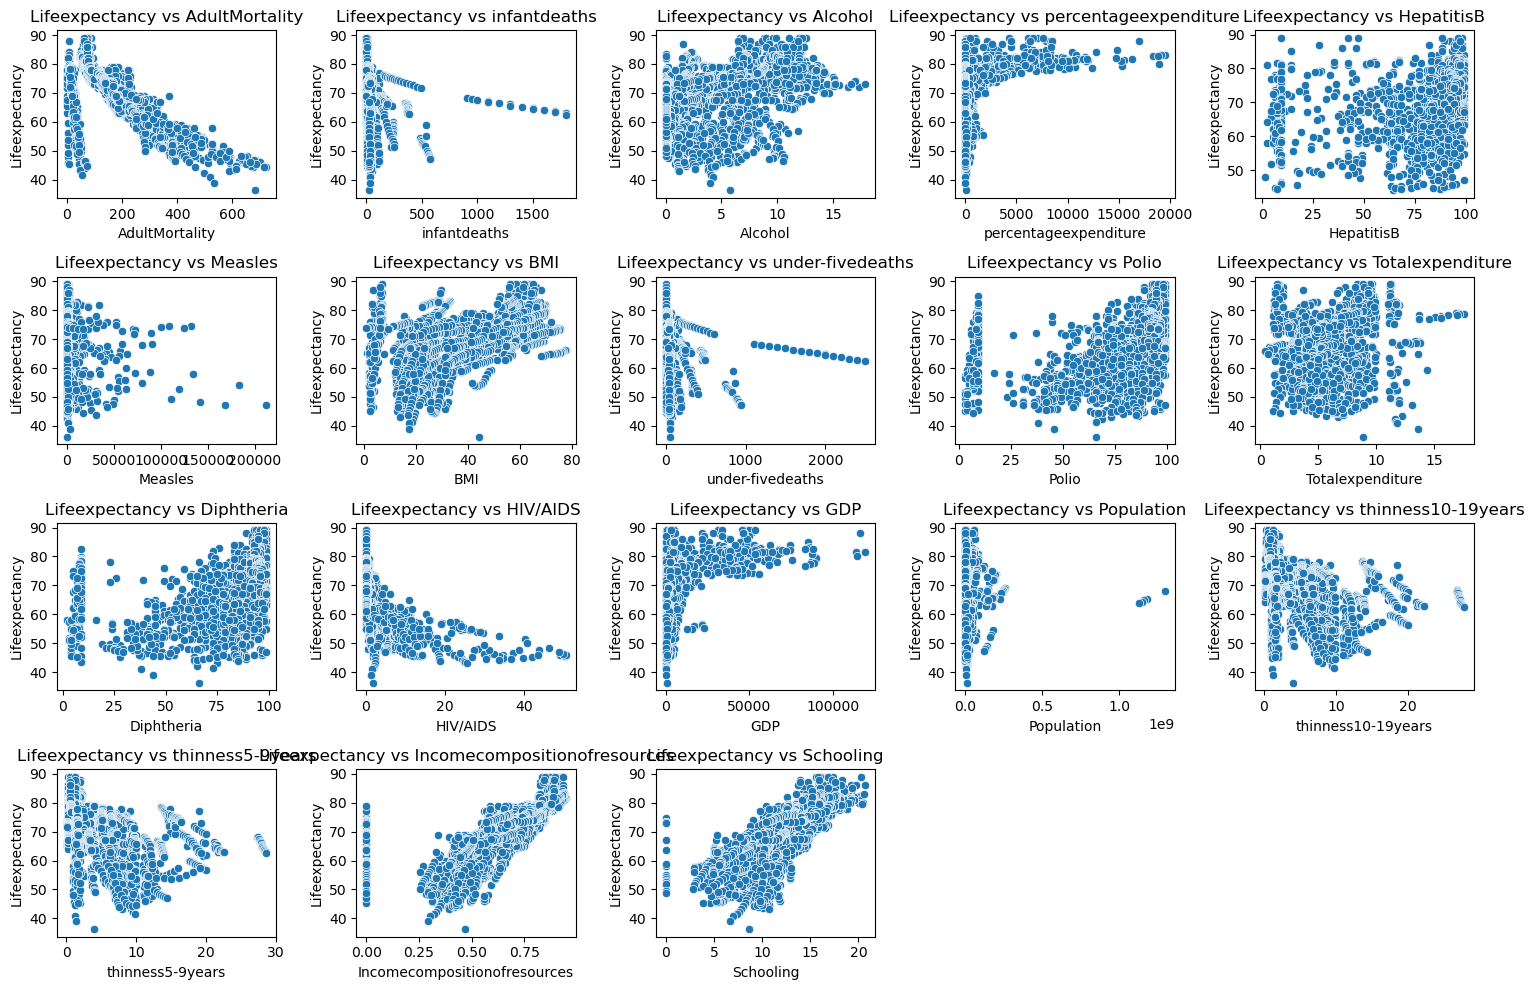

In [29]:
# Plot scatter plots for numeric variables against Lifeexpectancy
numeric_columns = ['AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
                   'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
                   'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years', 'thinness5-9years',
                   'Incomecompositionofresources', 'Schooling']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(4, 5, i)
    sns.scatterplot(x=df[col], y=df['Lifeexpectancy'])
    plt.title(f"Lifeexpectancy vs {col}")
    plt.xlabel(col)
    plt.ylabel('Lifeexpectancy')
plt.tight_layout()
plt.show()

## Missing Value Imputation and Outlliers Treatment

In [31]:
df.shape

(2938, 22)

In [32]:
df.isnull().sum().sum()

2563

In [33]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

1. Mean/Median Columns `['Alcohol', 'BMI', 'Totalexpenditure','thinness10-19years','thinness5-9years']`
  - These are continuous variables with moderate variability. Using mean or median captures the central tendency without being overly influenced by outliers.
2. Mode Columns `['HepatitisB', 'Polio', 'Diphtheria']`
  - These represent vaccination coverage percentages, which often cluster around common values (e.g., 90%+ in many regions). Mode reflects the most frequent and realistic value.

3. Predictive Columns: `['Lifeexpectancy', 'AdultMortality']`
  - These are complex features strongly correlated with other socio-economic and health indicators. Predictive modeling leverages these relationships to estimate missing values accurately.

4. Interpolation Columns: `['GDP', 'Population']`
  - These are time-series features that change gradually over years. Interpolation is effective for filling missing values by estimating trends based on surrounding data.

In [35]:
from sklearn.impute import SimpleImputer

In [36]:
mean_median_cols = ['Alcohol', 'BMI', 'Totalexpenditure','thinness10-19years','thinness5-9years']
mode_cols = ['HepatitisB', 'Polio', 'Diphtheria']

In [37]:
# Mean/Median Imputation
mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')

In [38]:
df[mean_median_cols] = mean_imputer.fit_transform(df[mean_median_cols])

In [39]:
# Mode Imputation
mode_imputer = SimpleImputer(strategy='most_frequent')
df[mode_cols] = mode_imputer.fit_transform(df[mode_cols])

In [40]:
df.isnull().sum().sum()

1450

In [41]:
df.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                   10
AdultMortality                   10
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                             448
Population                      652
thinness10-19years                0
thinness5-9years                  0
Incomecompositionofresources    167
Schooling                       163
dtype: int64

In [42]:
df[df['Lifeexpectancy'].isna()]

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
624,Cook Islands,2013,Developing,NaN,NaN,0,0.010000,0.000000,98.0,0,...,98.0,3.58,98.0,0.1,NaN,NaN,0.100000,0.100000,NaN,NaN
769,Dominica,2013,Developing,NaN,NaN,0,0.010000,11.419555,96.0,0,...,96.0,5.58,96.0,0.1,722.756650,NaN,2.700000,2.600000,0.721,12.7
1650,Marshall Islands,2013,Developing,NaN,NaN,0,0.010000,871.878317,8.0,0,...,79.0,17.24,79.0,0.1,3617.752354,NaN,0.100000,0.100000,NaN,0.0
1715,Monaco,2013,Developing,NaN,NaN,0,0.010000,0.000000,99.0,0,...,99.0,4.30,99.0,0.1,NaN,NaN,4.839704,4.870317,NaN,NaN
1812,Nauru,2013,Developing,NaN,NaN,0,0.010000,15.606596,87.0,0,...,87.0,4.65,87.0,0.1,136.183210,NaN,0.100000,0.100000,NaN,9.6
1909,Niue,2013,Developing,NaN,NaN,0,0.010000,0.000000,99.0,0,...,99.0,7.20,99.0,0.1,NaN,NaN,0.100000,0.100000,NaN,NaN
1958,Palau,2013,Developing,NaN,NaN,0,4.602861,344.690631,99.0,0,...,99.0,9.27,99.0,0.1,1932.122370,292.0,0.100000,0.100000,0.779,14.2
2167,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.540000,0.000000,97.0,0,...,96.0,6.14,96.0,0.1,NaN,NaN,3.700000,3.600000,0.749,13.4
2216,San Marino,2013,Developing,NaN,NaN,0,0.010000,0.000000,69.0,0,...,69.0,6.50,69.0,0.1,NaN,NaN,4.839704,4.870317,NaN,15.1
2713,Tuvalu,2013,Developing,NaN,NaN,0,0.010000,78.281203,9.0,0,...,9.0,16.61,9.0,0.1,3542.135890,1819.0,0.200000,0.100000,NaN,0.0


In [43]:
# drop rows having missing values in Lifeexpectancy
df.dropna(subset=['Lifeexpectancy'], inplace=True)

In [44]:
df.isna().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    0
AdultMortality                    0
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                             443
Population                      644
thinness10-19years                0
thinness5-9years                  0
Incomecompositionofresources    160
Schooling                       160
dtype: int64

In [45]:
# GDP and Population
df['GDP'].interpolate(method='linear', inplace=True)
df['Population'].interpolate(method='linear', inplace=True)

In [46]:
df.isna().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    0
AdultMortality                    0
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                               0
Population                        0
thinness10-19years                0
thinness5-9years                  0
Incomecompositionofresources    160
Schooling                       160
dtype: int64

In [47]:
# schooling and incomecompostitionsources group by country and fill with median
df['Incomecompositionofresources'].fillna(df.groupby('Status')['Incomecompositionofresources'].transform('median'), inplace=True)
df['Schooling'].fillna(df.groupby('Status')['Schooling'].transform('median'), inplace=True)

In [48]:
df.isna().sum()

Country                         0
Year                            0
Status                          0
Lifeexpectancy                  0
AdultMortality                  0
infantdeaths                    0
Alcohol                         0
percentageexpenditure           0
HepatitisB                      0
Measles                         0
BMI                             0
under-fivedeaths                0
Polio                           0
Totalexpenditure                0
Diphtheria                      0
HIV/AIDS                        0
GDP                             0
Population                      0
thinness10-19years              0
thinness5-9years                0
Incomecompositionofresources    0
Schooling                       0
dtype: int64

In [49]:
df.shape

(2928, 22)

In [50]:
df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', "Côte d'Ivoire", 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia', 'Fiji',
       'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany',
       'Ghana', 'Greece', 'Grenad

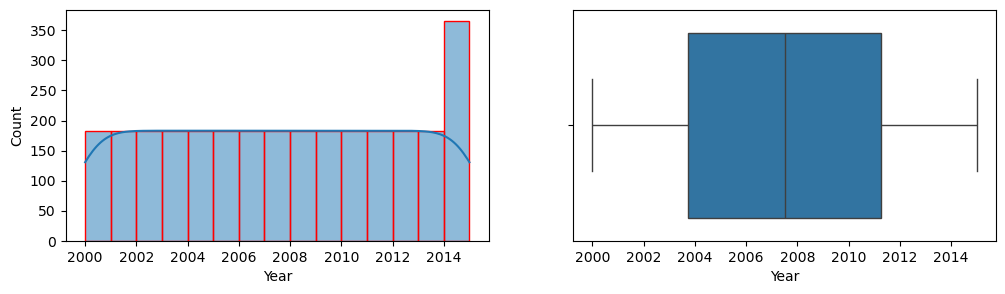

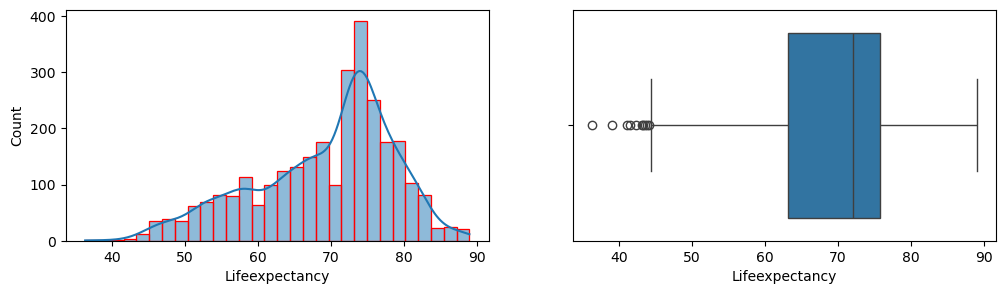

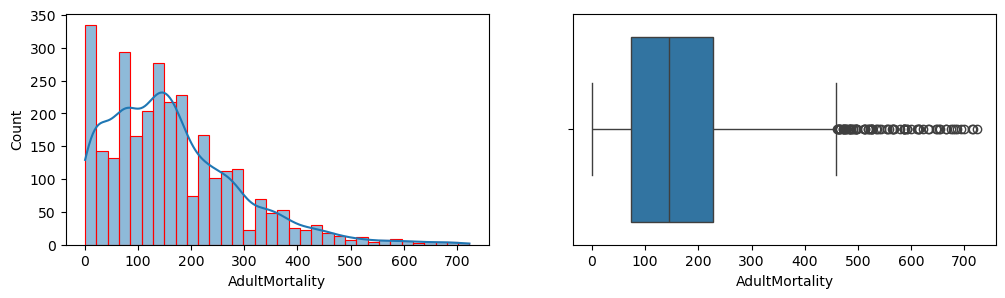

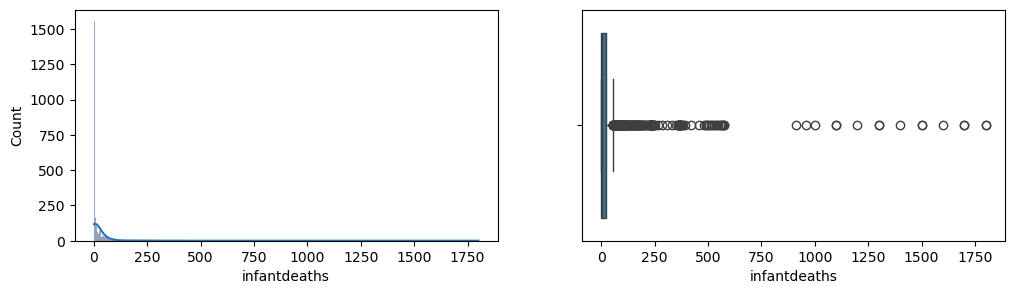

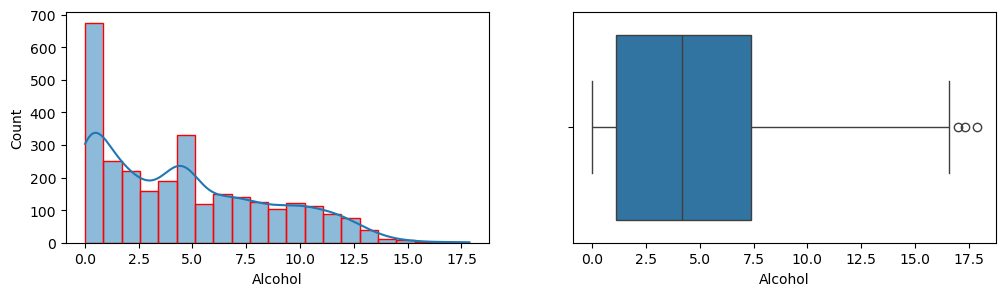

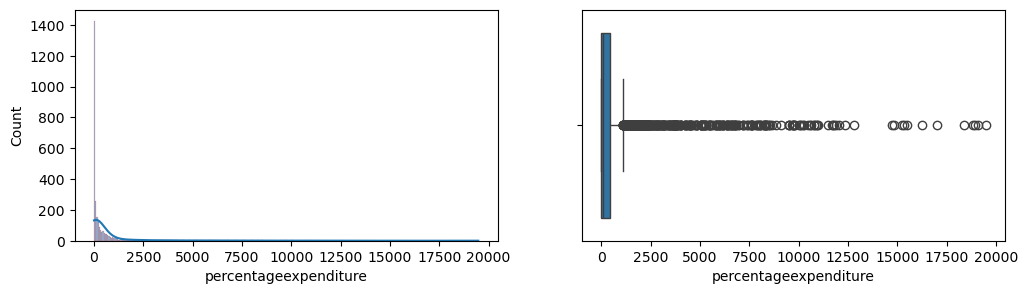

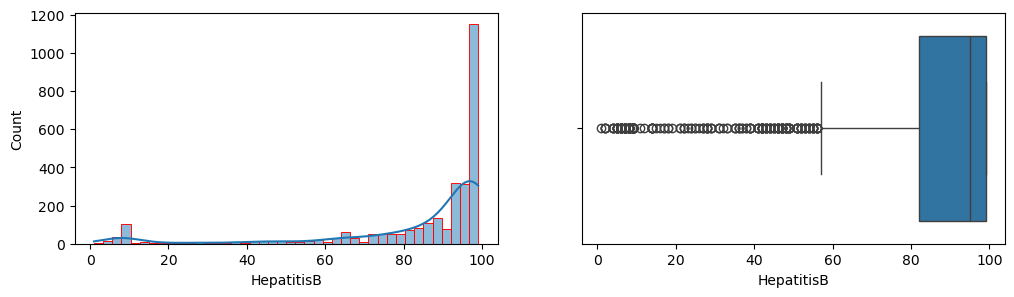

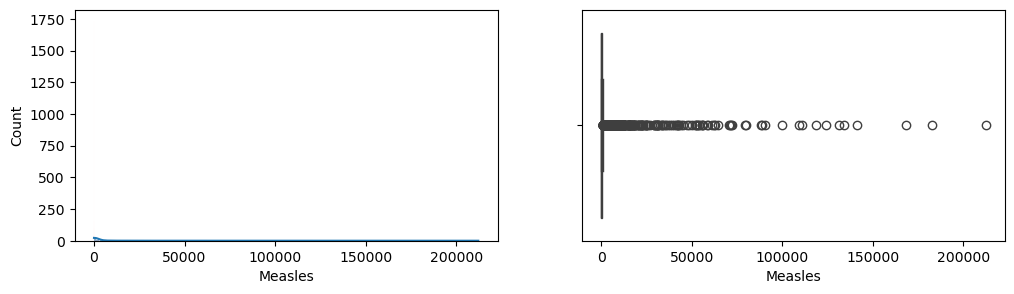

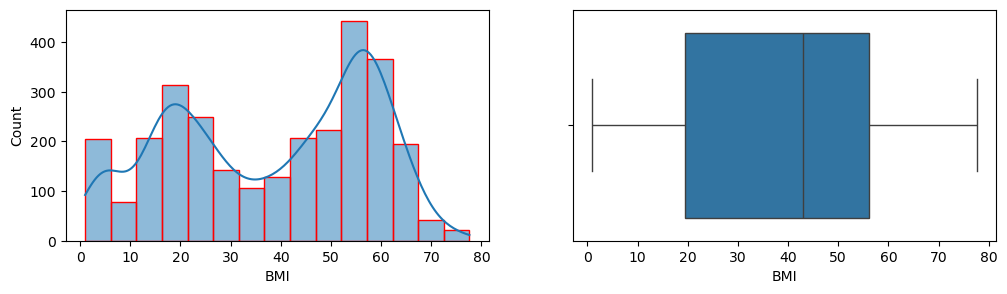

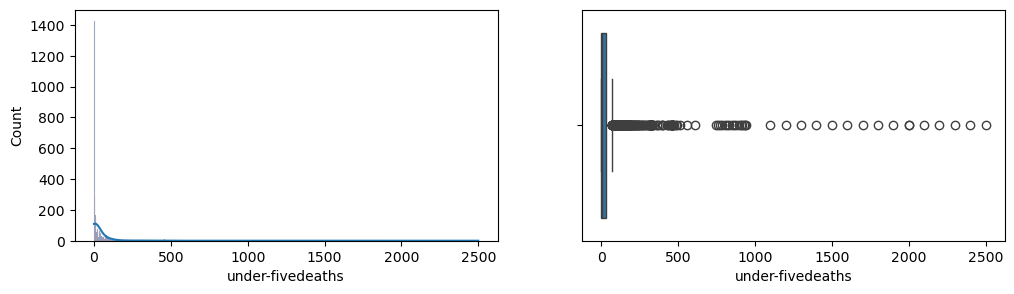

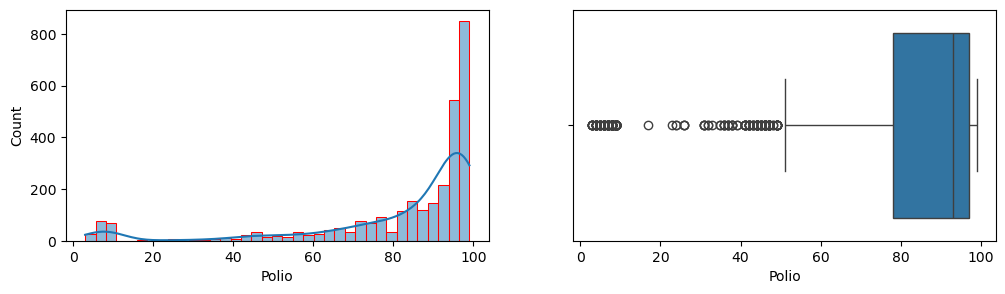

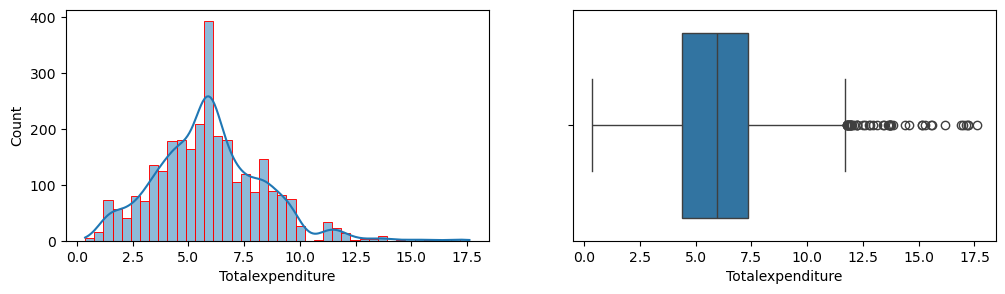

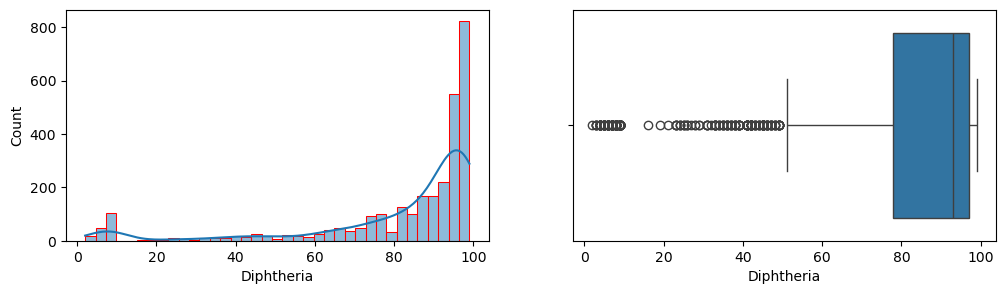

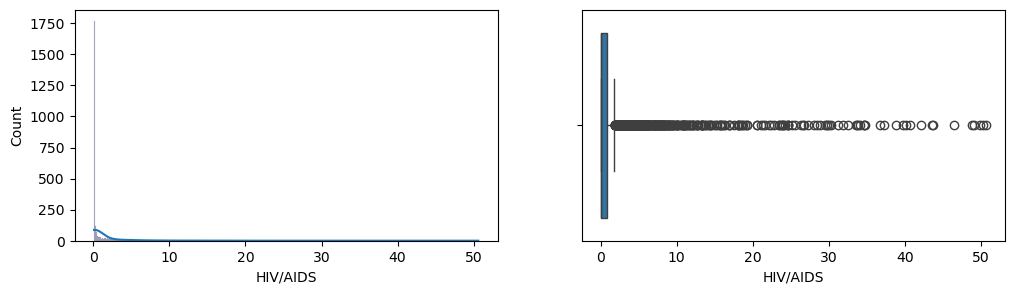

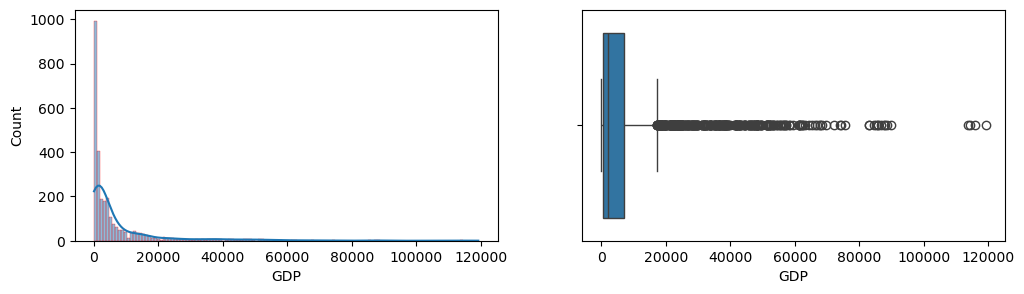

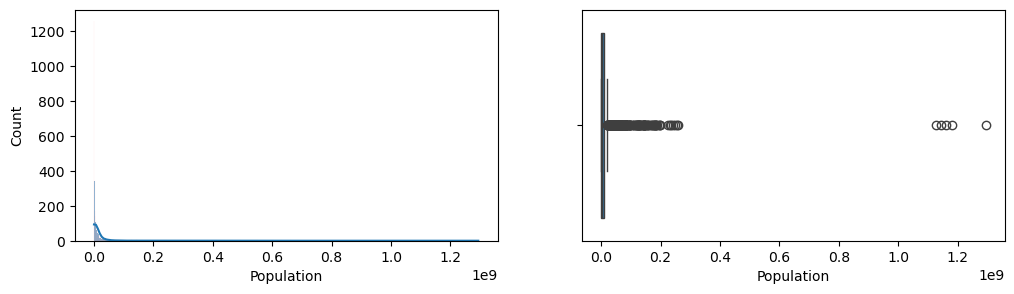

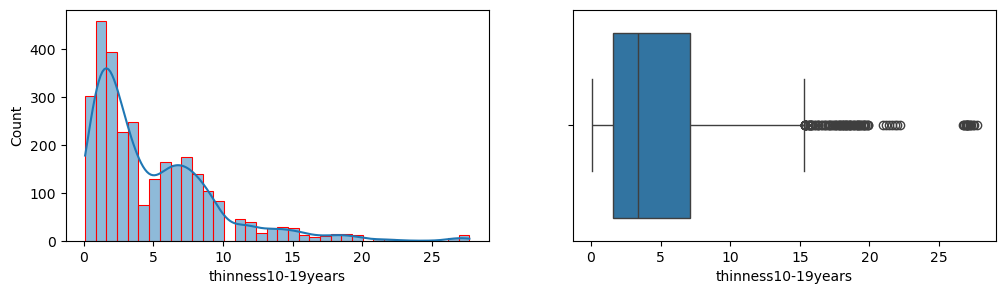

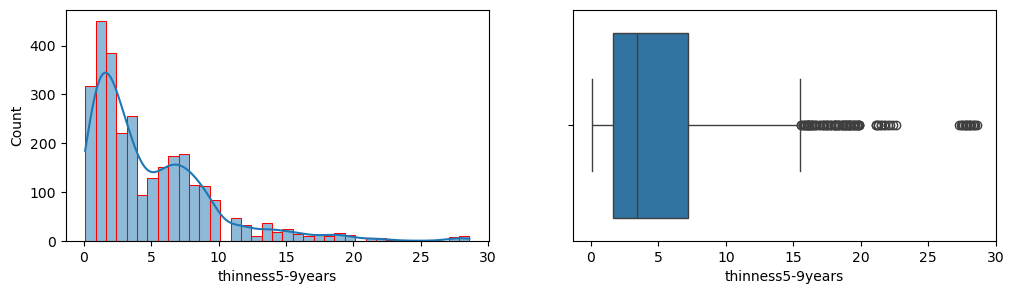

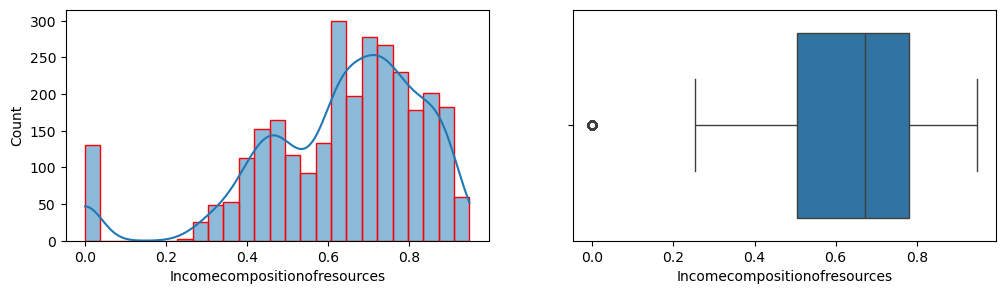

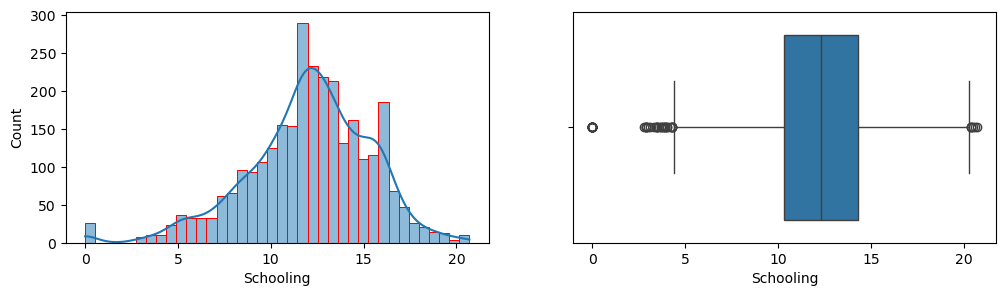

In [51]:
# histogram for all numerical columns

for i in df.columns:
  if df[i].dtype == 'float64' or df[i].dtype == 'int64':

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 2, 1)
    sns.histplot(data=df,
                x=i,
                kde=True,
                edgecolor='red')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df,x=i)

## Handeling Outliers

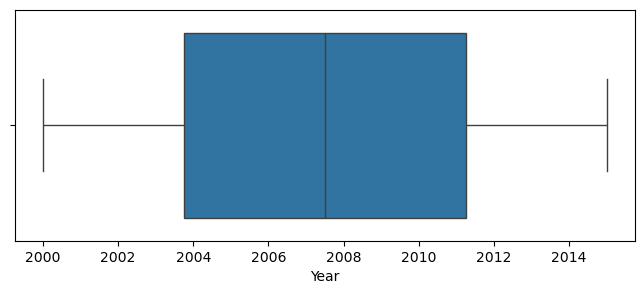

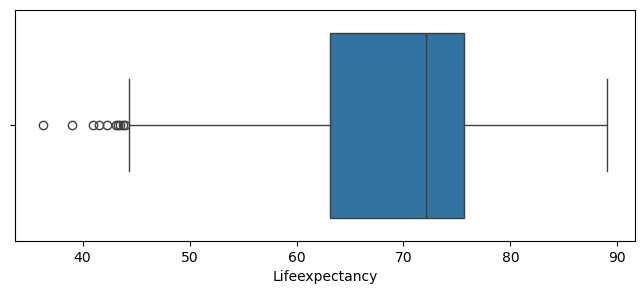

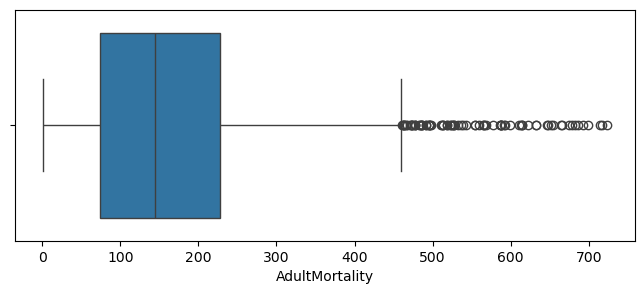

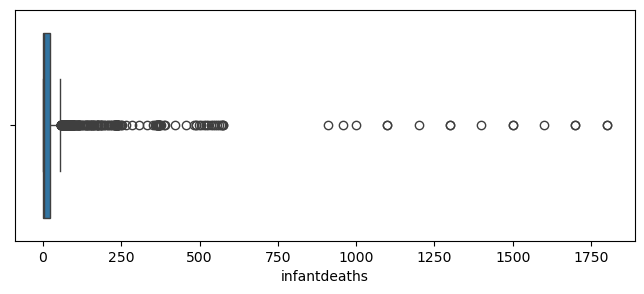

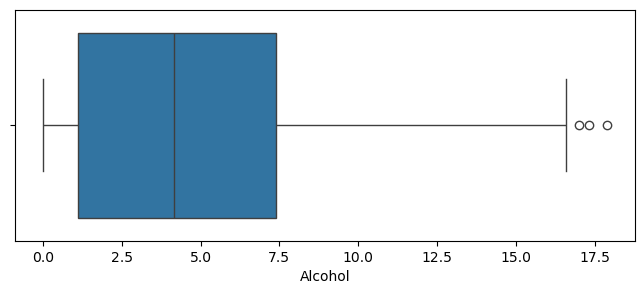

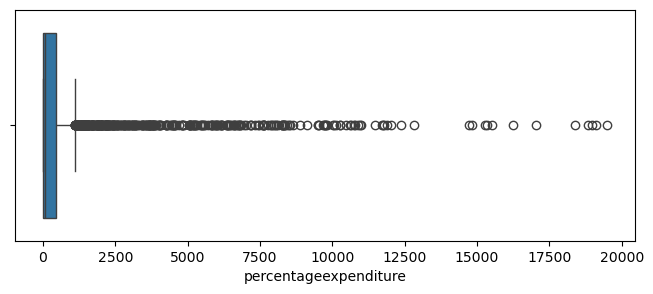

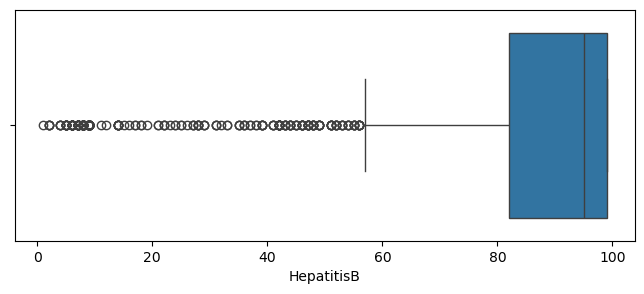

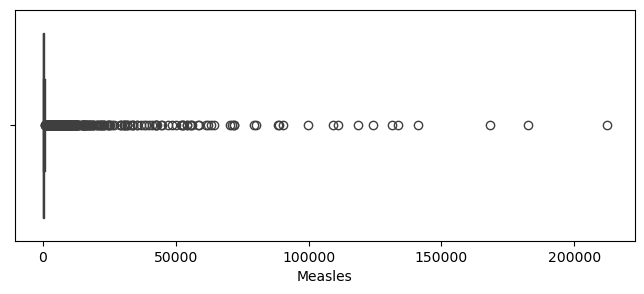

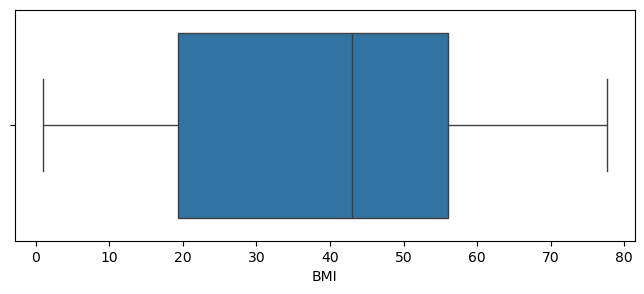

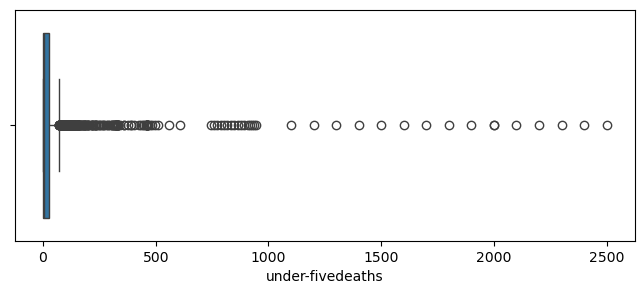

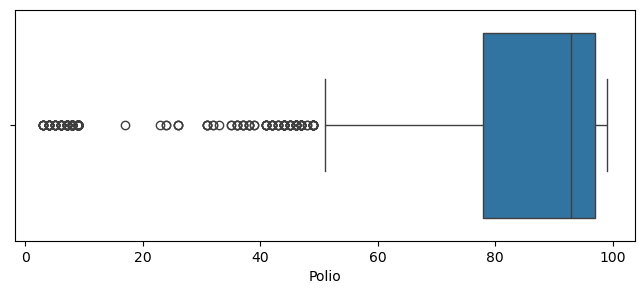

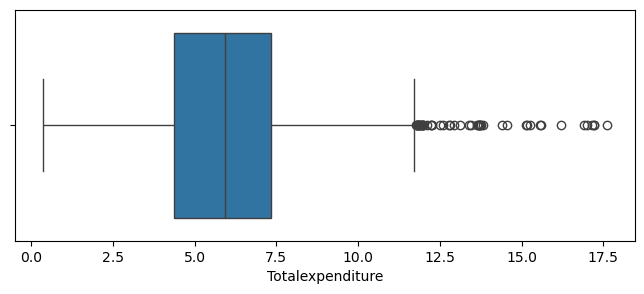

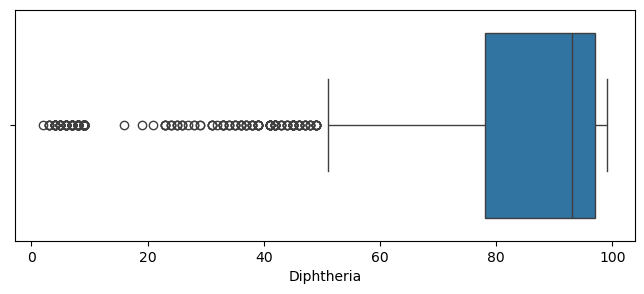

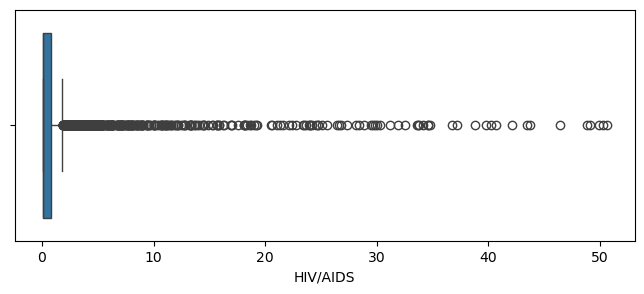

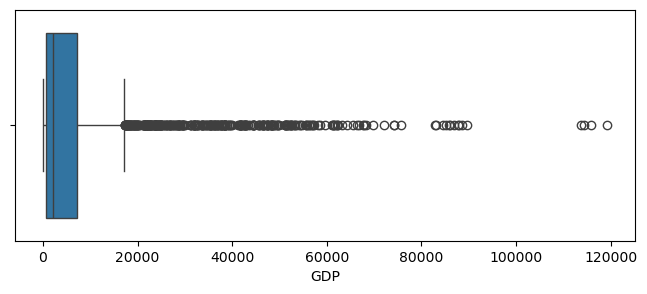

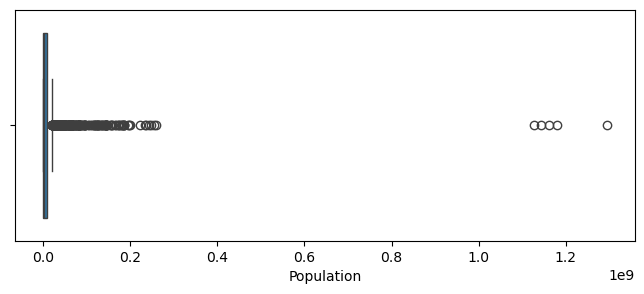

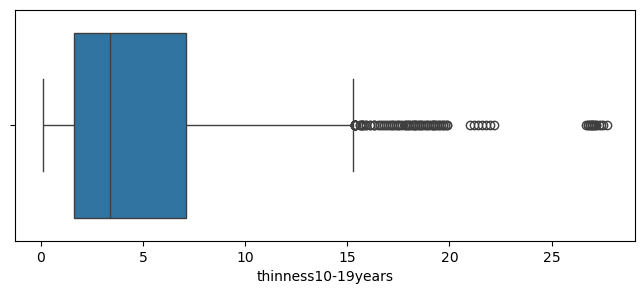

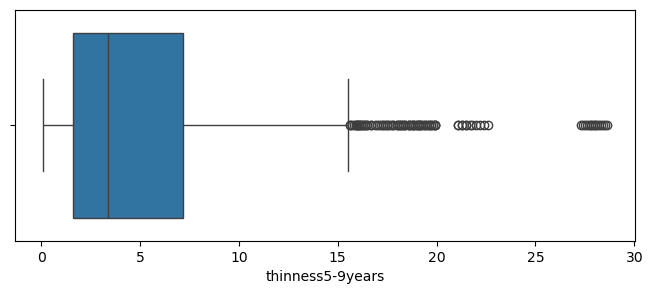

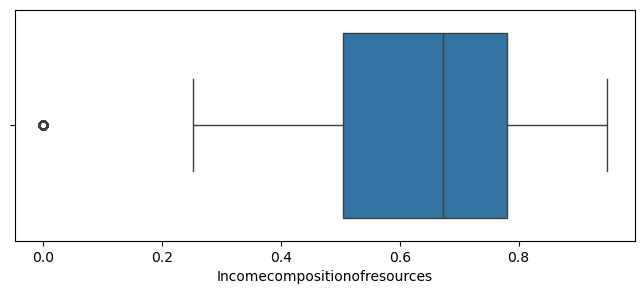

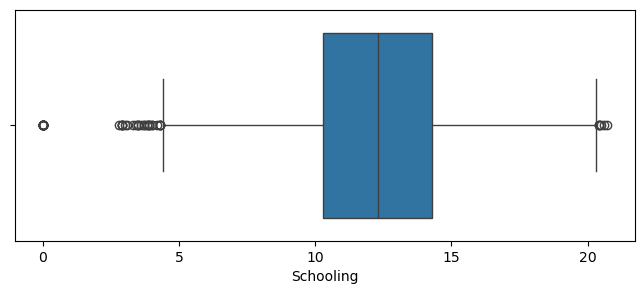

In [53]:
for i in df.columns:
  if df[i].dtype == 'float64' or df[i].dtype == 'int64':

    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df,x=i)

In [54]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

In [55]:
# treat outliners

cols_to_handle_outliers = [
    'AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure',
    'HepatitisB', 'Measles', 'BMI', 'under-fivedeaths', 'Polio',
    'Totalexpenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
    'thinness10-19years', 'thinness5-9years','Incomecompositionofresources', 'Schooling']

for col_name in cols_to_handle_outliers:
    # Calculate quartiles and IQR
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace outliers with the mean value of the column
    df[col_name] = np.where((df[col_name] > upper_bound) | (df[col_name] < lower_bound), np.mean(df[col_name]), df[col_name])

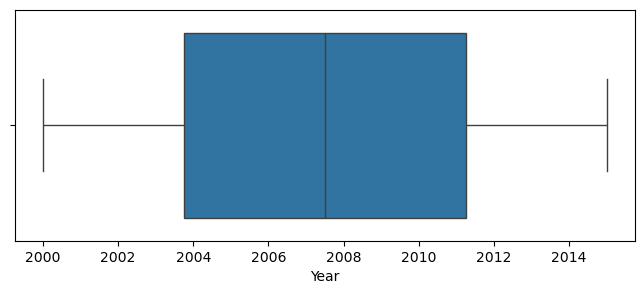

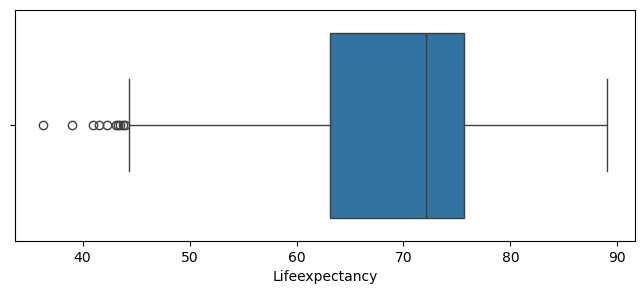

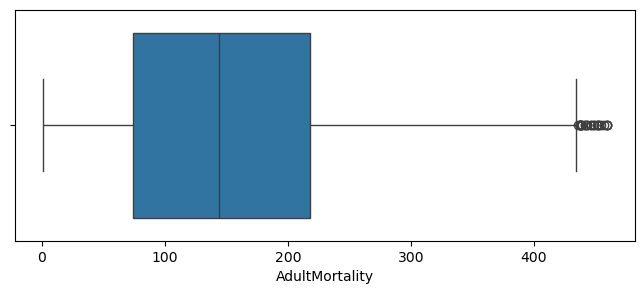

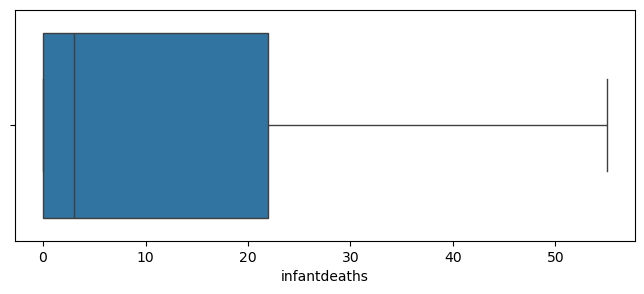

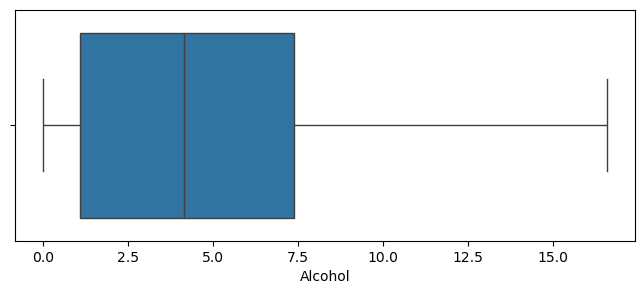

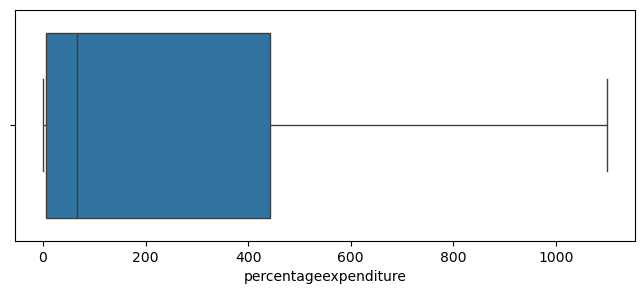

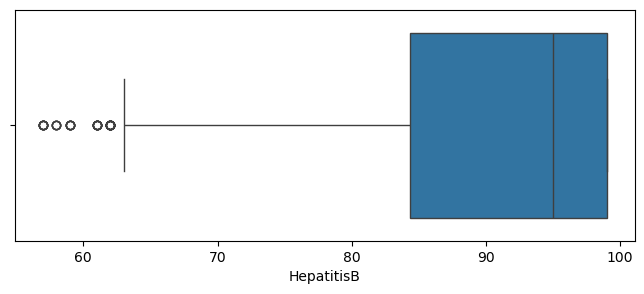

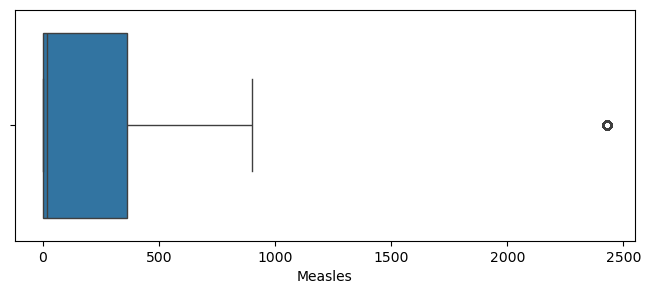

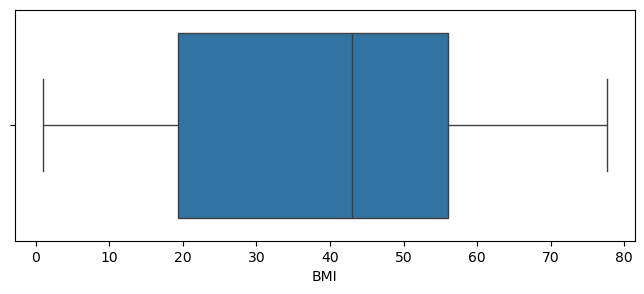

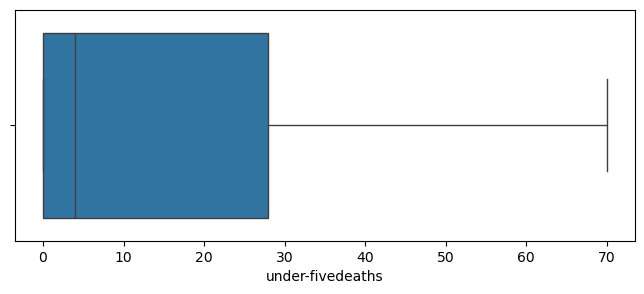

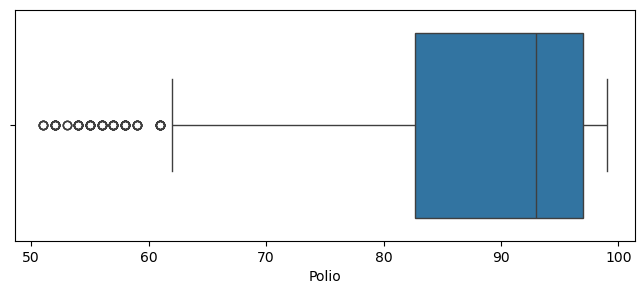

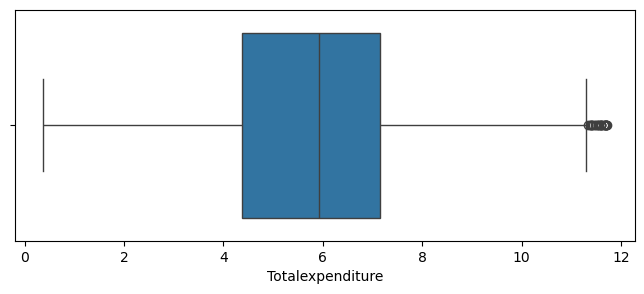

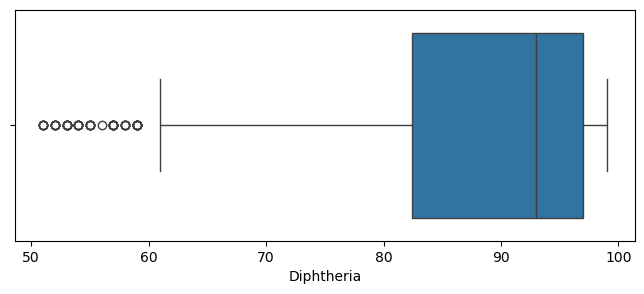

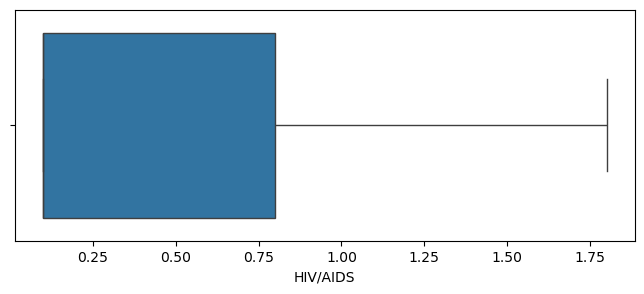

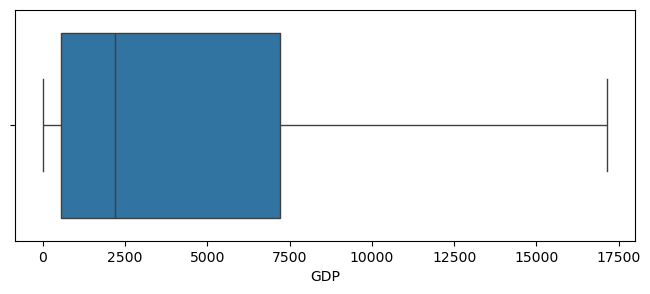

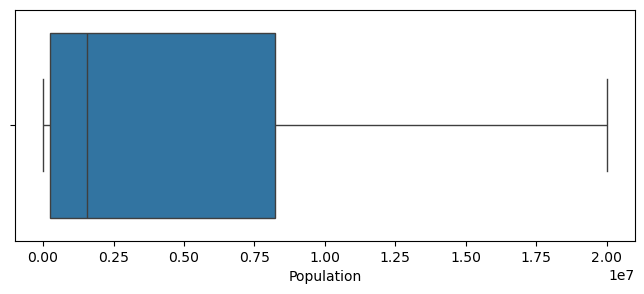

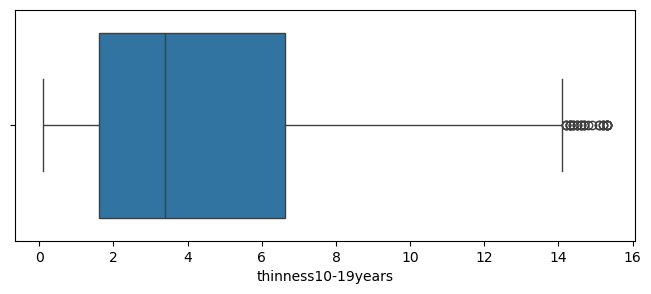

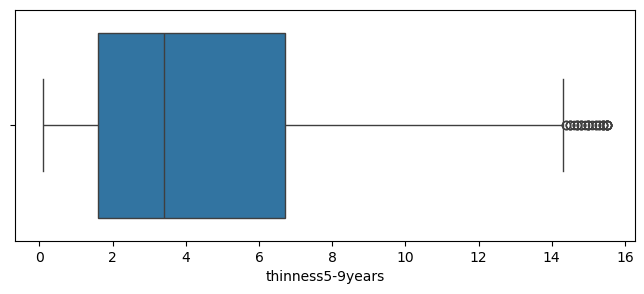

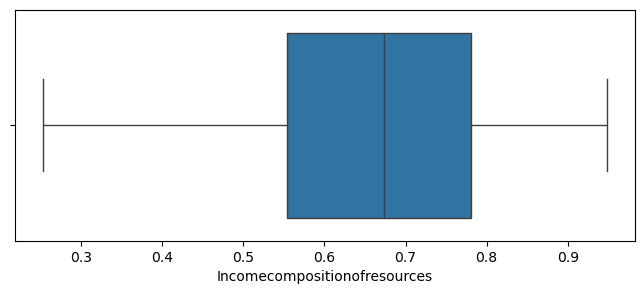

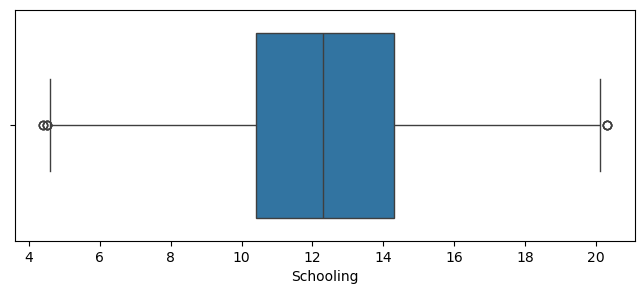

In [56]:
for i in df.columns:
  if df[i].dtype == 'float64' or df[i].dtype == 'int64':

    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df,x=i)

## Data Encoding

In [58]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,...,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,30.407445,0.01,73.523582,62.0,492.000000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,30.407445,0.01,73.219243,64.0,430.000000,...,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,30.407445,0.01,78.184215,67.0,2427.855874,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,30.407445,0.01,7.097109,68.0,2427.855874,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2928 non-null   object 
 1   Year                          2928 non-null   int64  
 2   Status                        2928 non-null   object 
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2928 non-null   float64
 6   Alcohol                       2928 non-null   float64
 7   percentageexpenditure         2928 non-null   float64
 8   HepatitisB                    2928 non-null   float64
 9   Measles                       2928 non-null   float64
 10  BMI                           2928 non-null   float64
 11  under-fivedeaths              2928 non-null   float64
 12  Polio                         2928 non-null   float64
 13  Totalexp

In [60]:
df.nunique()

Country                          183
Year                              16
Status                             2
Lifeexpectancy                   362
AdultMortality                   358
infantdeaths                      57
Alcohol                         1075
percentageexpenditure           1936
HepatitisB                        40
Measles                          426
BMI                              603
under-fivedeaths                  71
Polio                             46
Totalexpenditure                 774
Diphtheria                        46
HIV/AIDS                          19
GDP                             2581
Population                      2558
thinness10-19years               143
thinness5-9years                 146
Incomecompositionofresources     625
Schooling                        155
dtype: int64

In [61]:
df['Status'].value_counts()

Status
Developing    2416
Developed      512
Name: count, dtype: int64

In [62]:
# Binary Encoding
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})
df['Status'] = df['Status'].astype(int)

In [63]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,0,65.0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,...,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,Afghanistan,2014,0,59.9,271.0,30.407445,0.01,73.523582,62.0,492.000000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,Afghanistan,2013,0,59.9,268.0,30.407445,0.01,73.219243,64.0,430.000000,...,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,Afghanistan,2012,0,59.5,272.0,30.407445,0.01,78.184215,67.0,2427.855874,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,Afghanistan,2011,0,59.2,275.0,30.407445,0.01,7.097109,68.0,2427.855874,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


## Target Encoding

In [65]:
# Calculate the mean of the 'Target' variable for each category
category_means = df.groupby('Country')['Lifeexpectancy'].mean().round(2).to_dict()

# Map the means back to the 'Category' column to perform target encoding
df['Country'] = df['Country'].map(category_means)

In [66]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,58.19,2015,0,65.0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,...,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,58.19,2014,0,59.9,271.0,30.407445,0.01,73.523582,62.0,492.000000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,58.19,2013,0,59.9,268.0,30.407445,0.01,73.219243,64.0,430.000000,...,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,58.19,2012,0,59.5,272.0,30.407445,0.01,78.184215,67.0,2427.855874,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,58.19,2011,0,59.2,275.0,30.407445,0.01,7.097109,68.0,2427.855874,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2928 non-null   float64
 1   Year                          2928 non-null   int64  
 2   Status                        2928 non-null   int32  
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2928 non-null   float64
 6   Alcohol                       2928 non-null   float64
 7   percentageexpenditure         2928 non-null   float64
 8   HepatitisB                    2928 non-null   float64
 9   Measles                       2928 non-null   float64
 10  BMI                           2928 non-null   float64
 11  under-fivedeaths              2928 non-null   float64
 12  Polio                         2928 non-null   float64
 13  Totalexp

<Axes: >

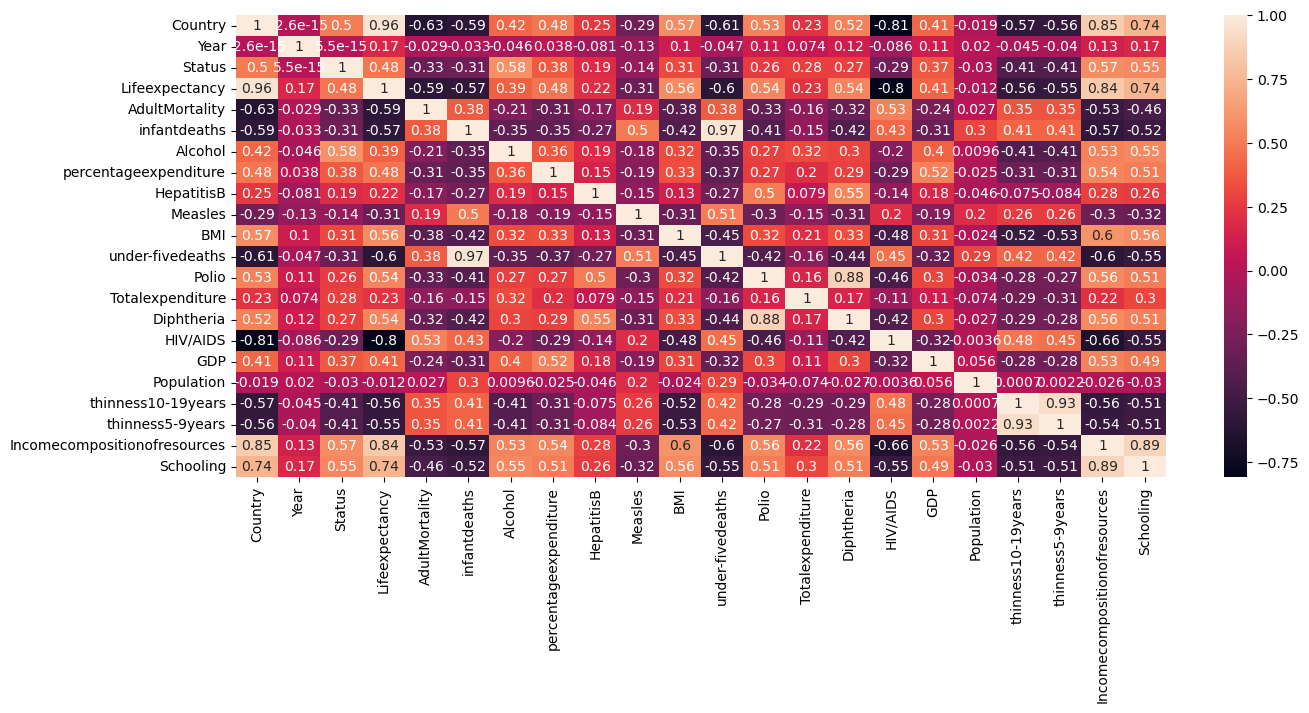

In [68]:
# plot correlation
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(), annot=True)

In [69]:
df.shape

(2928, 22)

## Model Building

In [71]:
# drop year
df.drop(['Year'],axis=1,inplace=True)

In [72]:
df.shape

(2928, 21)

In [73]:
X = df.drop(columns=["Lifeexpectancy"])
y = df["Lifeexpectancy"]

In [74]:
X

,Country,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,58.19,0,263.000000,30.407445,0.01,71.279624,65.000000,2427.855874,19.1,42.179303,82.655055,8.16,65.0,0.100000,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,58.19,0,271.000000,30.407445,0.01,73.523582,62.000000,492.000000,18.6,42.179303,58.000000,8.18,62.0,0.100000,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,58.19,0,268.000000,30.407445,0.01,73.219243,64.000000,430.000000,18.1,42.179303,62.000000,8.13,64.0,0.100000,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,58.19,0,272.000000,30.407445,0.01,78.184215,67.000000,2427.855874,17.6,42.179303,67.000000,8.52,67.0,0.100000,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,58.19,0,275.000000,30.407445,0.01,7.097109,68.000000,2427.855874,17.2,42.179303,68.000000,7.87,68.0,0.100000,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,50.49,0,164.796448,27.000000,4.36,0.000000,68.000000,31.000000,27.1,42.000000,67.000000,7.13,65.0,1.747712,454.366654,1.277751e+07,9.400000,9.400000,0.407,9.2
2934,50.49,0,164.796448,26.000000,4.06,0.000000,84.367828,2427.855874,26.7,41.000000,82.655055,6.52,68.0,1.747712,453.351155,1.263390e+07,9.800000,9.900000,0.418,9.5
2935,50.49,0,73.000000,25.000000,4.43,0.000000,73.000000,304.000000,26.3,40.000000,73.000000,6.53,71.0,1.747712,57.348340,1.255250e+05,1.200000,1.300000,0.427,10.0
2936,50.49,0,164.796448,25.000000,1.72,0.000000,76.000000,529.000000,25.9,39.000000,76.000000,6.16,75.0,1.747712,548.587312,1.236616e+07,1.600000,1.700000,0.427,9.8


In [75]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

In [76]:
X_train.shape, X_test.shape

((2342, 20), (586, 20))

## Feature Scaling

In [78]:
X_train.head()

,Country,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
2268,73.96,0,126.0,1.000000,9.380000,742.510971,97.0,0.000000,58.3,1.000000,93.0,9.89000,91.0,0.100000,5659.382400,7.199770e+05,2.1,2.1,0.767,14.0
1680,72.71,0,179.0,0.000000,4.140000,369.631710,88.0,0.000000,26.4,0.000000,88.0,4.24000,88.0,0.100000,3957.512960,1.246210e+05,7.9,7.9,0.683,12.5
2785,56.01,0,376.0,30.407445,3.440000,0.000000,86.0,2427.855874,19.6,42.179303,89.0,4.21000,86.0,1.747712,9324.039521,1.231209e+07,7.3,7.3,0.631,11.7
2512,82.52,1,62.0,0.000000,6.900000,740.321185,99.0,25.000000,56.5,0.000000,98.0,9.23000,98.0,0.100000,7453.307501,9.219637e+06,1.3,1.3,0.897,15.7
1090,55.37,0,275.0,4.000000,4.602861,0.000000,87.0,153.000000,26.3,6.000000,87.0,5.93819,87.0,1.747712,596.871719,1.775260e+05,7.1,7.0,0.421,9.2


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns= X_train.columns)
X_train_scaled.head()

,Country,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,0.527439,-0.457259,-0.277402,-0.702261,1.238776,1.684866,0.661461,-0.557909,1.015033,-0.724241,0.418820,1.903846,0.236729,-0.643488,0.469940,-0.714887,-0.666583,-0.666669,0.697525,0.603272
1,0.390969,-0.457259,0.233439,-0.772211,-0.115964,0.441970,-0.285187,-0.557909,-0.584495,-0.778382,-0.038821,-0.707098,-0.047733,-0.643488,0.046619,-0.827938,1.025289,1.017337,0.165286,0.100131
2,-1.432277,-0.457259,2.132226,1.354782,-0.296941,-0.790100,-0.495553,2.077342,-0.925461,1.505257,0.052707,-0.720962,-0.237374,1.848051,1.381482,1.486319,0.850267,0.843129,-0.164196,-0.168211
3,1.461989,2.186942,-0.894267,-0.772211,0.597601,1.677567,0.871827,-0.530774,0.924778,-0.778382,0.876462,1.598850,0.900472,-0.643488,0.916159,0.899098,-0.899944,-0.898945,1.521228,1.173499
4,-1.502150,-0.457259,1.158736,-0.492412,0.003703,-0.790100,-0.390370,-0.391840,-0.589510,-0.453535,-0.130350,0.077659,-0.142554,1.848051,-0.789302,-0.817892,0.791927,0.756026,-1.494793,-1.006780


## Linear Regression Model

In [81]:
from sklearn.linear_model import LinearRegression

modelLR = LinearRegression()
modelLR.fit(X_train_scaled, y_train)

LinearRegression()

In [82]:
y_pred = modelLR.predict(X_test_scaled)

In [83]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

def evaluate_model(y_test,y_pred):
  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  scores = {
      "Mean Squared Error": mse,
      "Mean Absolute Error": mae,
      "Root Mean Squared Error": rmse,
      "R2 Score": r2
  }
  return scores

In [84]:
evaluate_model(y_test,y_pred)

{'Mean Squared Error': 5.898657218852804,
 'Mean Absolute Error': 1.6831494757945518,
 'Root Mean Squared Error': 2.428715137444654,
 'R2 Score': 0.9318069598117212}

In [85]:
# build KNN Regression model
from sklearn.neighbors import KNeighborsRegressor

modelKNN = KNeighborsRegressor(n_neighbors=5,
                               n_jobs=-1)

modelKNN.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_jobs=-1)

In [86]:
y_pred_knn = modelKNN.predict(X_test_scaled)

In [87]:
evaluate_model(y_test,y_pred_knn)

{'Mean Squared Error': 7.046619112627987,
 'Mean Absolute Error': 1.8487030716723551,
 'Root Mean Squared Error': 2.6545468751988515,
 'R2 Score': 0.9185356323464429}

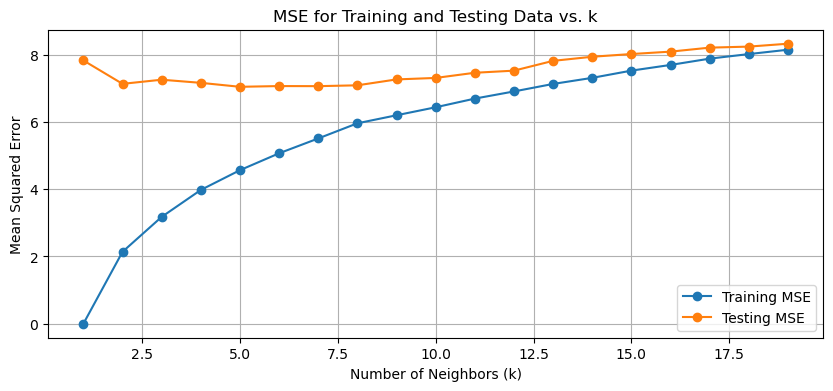

In [88]:
train_mse = []
test_mse = []

k_values = range(1,20)

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors = k,n_jobs=-1)
    knn.fit(X_train_scaled, y_train)

    # Predictions for train and test sets
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)


    # Calculate MSE
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))


plt.figure(figsize=(10, 4))
plt.plot(k_values, train_mse, label='Training MSE', marker='o')
plt.plot(k_values, test_mse, label='Testing MSE', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.title('MSE for Training and Testing Data vs. k')
plt.legend()
plt.grid()
plt.show()

## SVR Model

In [90]:
from sklearn.svm import SVR

modelSVR = SVR()
modelSVR.fit(X_train_scaled, y_train)

SVR()

In [91]:
y_pred_SVR = modelSVR.predict(X_test_scaled)

In [92]:
evaluate_model(y_test,y_pred_SVR)

{'Mean Squared Error': 6.883454364402457,
 'Mean Absolute Error': 1.7146824596563195,
 'Root Mean Squared Error': 2.6236338091285636,
 'R2 Score': 0.9204219430473752}

## Decision Tree Regression

In [94]:
from sklearn.tree import DecisionTreeRegressor

modelDTR = DecisionTreeRegressor(random_state=42)
modelDTR.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [95]:
y_pred_DTR = modelDTR.predict(X_test)

In [96]:
evaluate_model(y_test,y_pred_DTR)

{'Mean Squared Error': 4.674965870307167,
 'Mean Absolute Error': 1.2353242320819113,
 'Root Mean Squared Error': 2.162166938584338,
 'R2 Score': 0.9459537783525096}

## Regularization

In [98]:
from sklearn.linear_model import Lasso

# lssso regression
lasso = Lasso(alpha=0.001)  # Adjust alpha for stronger/weaker regularization
lasso.fit(X_train_scaled, y_train)

# Display Lasso Coefficients
print("Lasso Coefficients:")
for feature, coef in zip(X.columns, lasso.coef_):
    print(f"{feature}: {coef:.4f}")

Lasso Coefficients:
Country: 7.9106
Status: 0.0788
AdultMortality: 0.1626
infantdeaths: 0.3991
Alcohol: -0.3337
percentageexpenditure: 0.0895
HepatitisB: -0.5790
Measles: -0.2267
BMI: -0.0694
under-fivedeaths: -0.4846
Polio: 0.0329
Totalexpenditure: 0.1055
Diphtheria: 0.5452
HIV/AIDS: -0.4951
GDP: -0.0542
Population: 0.1063
thinness10-19years: -0.0012
thinness5-9years: -0.0587
Incomecompositionofresources: 0.8389
Schooling: 0.0881


## Feature Selection:

In [100]:
df.columns

Index(['Country', 'Status', 'Lifeexpectancy', 'AdultMortality', 'infantdeaths',
       'Alcohol', 'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

Need to select the features properly, here we checked how the model will work if we remove `Country` which has high correlation with target.

In [102]:
X.columns

Index(['Country', 'Status', 'AdultMortality', 'infantdeaths', 'Alcohol',
       'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness10-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

In [103]:
selected_features = X.drop(columns=['Country'])
selected_features.head()

,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,19.1,42.179303,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,0,271.0,30.407445,0.01,73.523582,62.0,492.000000,18.6,42.179303,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,0,268.0,30.407445,0.01,73.219243,64.0,430.000000,18.1,42.179303,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,0,272.0,30.407445,0.01,78.184215,67.0,2427.855874,17.6,42.179303,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,0,275.0,30.407445,0.01,7.097109,68.0,2427.855874,17.2,42.179303,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [104]:
X = selected_features
y = df["Lifeexpectancy"]

In [105]:
X

,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness10-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,0,263.000000,30.407445,0.01,71.279624,65.000000,2427.855874,19.1,42.179303,82.655055,8.16,65.0,0.100000,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,0,271.000000,30.407445,0.01,73.523582,62.000000,492.000000,18.6,42.179303,58.000000,8.18,62.0,0.100000,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,0,268.000000,30.407445,0.01,73.219243,64.000000,430.000000,18.1,42.179303,62.000000,8.13,64.0,0.100000,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,0,272.000000,30.407445,0.01,78.184215,67.000000,2427.855874,17.6,42.179303,67.000000,8.52,67.0,0.100000,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,0,275.000000,30.407445,0.01,7.097109,68.000000,2427.855874,17.2,42.179303,68.000000,7.87,68.0,0.100000,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0,164.796448,27.000000,4.36,0.000000,68.000000,31.000000,27.1,42.000000,67.000000,7.13,65.0,1.747712,454.366654,1.277751e+07,9.400000,9.400000,0.407,9.2
2934,0,164.796448,26.000000,4.06,0.000000,84.367828,2427.855874,26.7,41.000000,82.655055,6.52,68.0,1.747712,453.351155,1.263390e+07,9.800000,9.900000,0.418,9.5
2935,0,73.000000,25.000000,4.43,0.000000,73.000000,304.000000,26.3,40.000000,73.000000,6.53,71.0,1.747712,57.348340,1.255250e+05,1.200000,1.300000,0.427,10.0
2936,0,164.796448,25.000000,1.72,0.000000,76.000000,529.000000,25.9,39.000000,76.000000,6.16,75.0,1.747712,548.587312,1.236616e+07,1.600000,1.700000,0.427,9.8


In [106]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)

In [107]:
X_train.shape, X_test.shape

((2342, 19), (586, 19))

In [108]:
y_train.shape, y_test.shape

((2342,), (586,))

In [109]:
# data scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [111]:
# train model
lasso_modelLR = LinearRegression()
lasso_modelLR.fit(X_train_scaled, y_train)

# prediction
y_pred = lasso_modelLR.predict(X_test_scaled)

#evaluation
evaluate_model(y_test,y_pred)

{'Mean Squared Error': 14.42087582707248,
 'Mean Absolute Error': 2.805905214121564,
 'Root Mean Squared Error': 3.797482827752152,
 'R2 Score': 0.8332835205811489}

In [112]:
results = evaluate_model(y_test,y_pred)
R2_LR = results['R2 Score']
print(R2_LR)

0.8332835205811489


## KNN Regression

In [114]:
# train model
lasso_modelKNN = KNeighborsRegressor(n_neighbors=5,
                               n_jobs=-1)

lasso_modelKNN.fit(X_train_scaled, y_train)

# prediction
y_pred_knn = lasso_modelKNN.predict(X_test_scaled)

#evaluation
evaluate_model(y_test,y_pred_knn)

{'Mean Squared Error': 7.928614334470989,
 'Mean Absolute Error': 1.9745392491467575,
 'Root Mean Squared Error': 2.815779525188538,
 'R2 Score': 0.9083390853396468}

## SVR Regression

In [116]:
# train model
lasso_modelSVR = SVR()
lasso_modelSVR.fit(X_train_scaled, y_train)

# prediction
y_pred_SVR = lasso_modelSVR.predict(X_test_scaled)

#evaluation
evaluate_model(y_test,y_pred_SVR)

{'Mean Squared Error': 11.394260126804449,
 'Mean Absolute Error': 2.2601814451886586,
 'Root Mean Squared Error': 3.375538494344932,
 'R2 Score': 0.868273539228646}

## Decision Tree Regression

In [213]:
# train model
lasso_modelDTR = DecisionTreeRegressor(random_state=42)
lasso_modelDTR.fit(X_train, y_train)

# prediction
y_pred_DTR = lasso_modelDTR.predict(X_test)

#evaluation
evaluate_model(y_test,y_pred_DTR)

{'Mean Squared Error': 7.300375426621161,
 'Mean Absolute Error': 1.6668941979522187,
 'Root Mean Squared Error': 2.7019206921412704,
 'R2 Score': 0.9156020130707103}

## Hyperparameter Tuning

In [215]:
from sklearn.model_selection import GridSearchCV

### Decision Tree

In [217]:
# Decision Tree
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

In [219]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error', verbose=1)

In [221]:
# Best Parameters
print("Best Parameters:", grid_search.best_params_)

# Best Model
best_dt = grid_search.best_estimator_

# Predictions
y_pred_GS_DTR = best_dt.predict(X_test)

# evaluation
evaluate_model(y_test,y_pred_GS_DTR)

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


{'Mean Squared Error': 6.532764293249938,
 'Mean Absolute Error': 1.6820962580949534,
 'Root Mean Squared Error': 2.5559272863776736,
 'R2 Score': 0.9244761915362177}

In [223]:
results = evaluate_model(y_test,y_pred_GS_DTR)
R2_DTR = results['R2 Score']
print(R2_DTR)

0.9244761915362177


### KNN 

In [225]:
# Hyperparameter Grid
knn_params = {
    'n_neighbors': [5,7,10,12,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [227]:
knn = KNeighborsRegressor()

grid_knn = GridSearchCV(knn,
                        knn_params,
                        cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1,
                        verbose=1)

grid_knn.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [5, 7, 10, 12, 15],
                         'weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=1)

In [229]:
# best parameters
print("Best KNN Parameters:", grid_knn.best_params_)

# best model
best_knn = grid_knn.best_estimator_

# prediction
y_pred_GS_KNN = best_knn.predict(X_test_scaled)

#evaluation
evaluate_model(y_test,y_pred_GS_KNN)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


{'Mean Squared Error': 4.730764851949236,
 'Mean Absolute Error': 1.4038714704259725,
 'Root Mean Squared Error': 2.1750321496357787,
 'R2 Score': 0.9453086989630137}

In [231]:
results = evaluate_model(y_test,y_pred_GS_KNN)
R2_KNN = results['R2 Score']
print(R2_KNN)

0.9453086989630137


### SVR

In [233]:
# param grid
svr_params = {
    'kernel': ['linear','rbf'],
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.2, 0.5, 1.0]
}

In [235]:
svr = SVR()

grid_svr = GridSearchCV(svr,
                        svr_params,
                        cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1,
                        verbose = 1)

grid_svr.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'epsilon': [0.1, 0.2, 0.5, 1.0],
                         'kernel': ['linear', 'rbf']},
             scoring='neg_mean_squared_error', verbose=1)

In [237]:
print("Best SVR Parameters:", grid_svr.best_estimator_)

# best model
best_svr = grid_svr.best_estimator_

# prediciton
y_pred_GS_SVR = best_svr.predict(X_test_scaled)

#evaluation
evaluate_model(y_test,y_pred_GS_SVR)

Best SVR Parameters: SVR(C=10, epsilon=0.2)


{'Mean Squared Error': 7.060742993197669,
 'Mean Absolute Error': 1.6330598963948693,
 'Root Mean Squared Error': 2.6572058620283205,
 'R2 Score': 0.9183723493619317}

In [239]:
results = evaluate_model(y_test,y_pred_GS_SVR)
R2_SVR = results['R2 Score']
print(R2_SVR)

0.9183723493619317


## Model Comparison

Text(0.5, 1.0, 'Comparison of Model Scores')

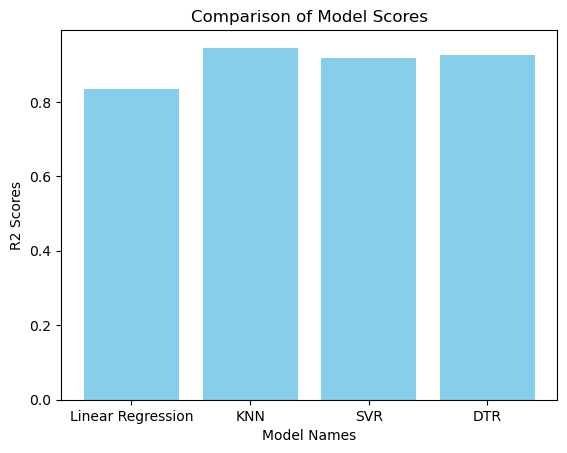

In [241]:
model_names = ['Linear Regression','KNN','SVR','DTR']
model_scores = [R2_LR,R2_KNN,R2_SVR,R2_DTR]

# bar graph
plt.bar(model_names, model_scores, color='skyblue')
plt.xlabel('Model Names')
plt.ylabel('R2 Scores')
plt.title('Comparison of Model Scores')